# Regression Project

In [47]:
from pandas import read_csv
import pandas as pd
import numpy as np

df_sales = read_csv('./files/sales.csv', index_col=0, na_values=["NA", "N/a", "?", ""])

In [32]:
df_sales.head()

,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
425390,366,4,2013-04-18,517,1,0,0,0,4422
291687,394,6,2015-04-11,694,1,0,0,0,8297
411278,807,4,2013-08-29,970,1,1,0,0,9729
664714,802,2,2013-05-28,473,1,1,0,0,6513
540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [33]:
df_sales.describe()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [15]:
df_sales.keys()

Index(['store_ID', 'day_of_week', 'date', 'nb_customers_on_day', 'open',
       'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='object')

In [34]:
df_sales.dtypes

store_ID                int64
day_of_week             int64
date                   object
nb_customers_on_day     int64
open                    int64
promotion               int64
state_holiday          object
school_holiday          int64
sales                   int64
dtype: object

## Pre-processing the data

* Check if there are any null or nan or ? values on our df

In [37]:
df_sales.isnull().values.any()

df_sales.isnull().sum()

store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

* Check for duplicates

In [38]:
df_sales.duplicated().sum()

0

* Drop columns that might pose a problem on predictions

In [46]:
# Check if store_id is unique 
df_sales['store_ID'].nunique(), df_sales.shape[0]

(1115, 640840)

* Convert state holidays in numerical values. a, b, and c to 1 as it is a state holiday

In [48]:
df_sales['state_holiday'] = df_sales['state_holiday'].apply(lambda x: 0 if x=='0' else 1)

In [49]:

# as store_id is not unique we cannot drop it but we will drop date
df_feature = df_sales.drop('date', axis=1)

* Categorical columns
- one-hot encoding
- label encoding if values are ordinal

* Regression models (like OLS or linear regression) are sensitive to the scale of the data.
-  Standardize (mean 0, std 1): StandardScaler
-  Normalize (0 to 1): MinMaxScaler

In [50]:
df_feature.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
425390,366,4,517,1,0,0,0,4422
291687,394,6,694,1,0,0,0,8297
411278,807,4,970,1,1,0,0,9729
664714,802,2,473,1,1,0,0,6513
540835,726,4,1068,1,1,0,0,10882


In [66]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Separate Features from target
X = df_feature.drop('sales', axis=1)  
y = df_feature['sales']  

X.dtypes
y.dtypes



dtype('int64')

In [67]:
X

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
425390,366,4,517,1,0,0,0
291687,394,6,694,1,0,0,0
411278,807,4,970,1,1,0,0
664714,802,2,473,1,1,0,0
540835,726,4,1068,1,1,0,0
...,...,...,...,...,...,...,...
359783,409,6,483,1,0,0,0
152315,97,1,987,1,1,0,0
117952,987,1,925,1,0,0,0
435829,1084,4,725,1,0,0,0


In [68]:
y

425390     4422
291687     8297
411278     9729
664714     6513
540835    10882
          ...  
359783     4553
152315    12307
117952     6800
435829     5344
305711        0
Name: sales, Length: 640840, dtype: int64

In [52]:
from sklearn.model_selection import train_test_split

# Split in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check train and test sizes
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

(640840, 7) (512672, 7) (128168, 7)
(640840,) (512672,) (128168,)


In [54]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

# Create the linear regression estimator
lm = LinearRegression()

# Perform the fitting 
lm.fit(X_train, y_train)

print('coef ', lm.coef_)
print('intercept ', lm.intercept_)

coef  [-1.44627998e-01 -7.72294715e+01  6.07484928e+00  1.47673509e+03
  1.28442018e+03 -7.73864123e+02  6.35338748e+01]
intercept  616.2059052249224


## Evaluate the model

In [61]:
from sklearn.metrics import r2_score

y_pred = lm.predict(X_test)
y_pred.shape


(128168,)

In [63]:
y_pred

array([9678.45262255,  -48.2019617 , 5265.93648882, ..., 9681.04080698,
       8847.05707378, 7676.64162195])

In [64]:
y_test

173548    10108
645051        0
158198     4232
188226     5189
711780     5318
          ...  
328323     4432
560479        0
576131    10476
697717     8641
355901     8484
Name: sales, Length: 128168, dtype: int64

In [69]:
mae = np.mean(np.absolute(y_pred - y_test))
print("Mean Absolute Error: %.2f" % mae)

r2_train = r2_score(y_test, y_pred)
print("R2-score: ", r2_train ) 

Mean Absolute Error: 981.86
R2-score:  0.8510121055534356


Check the range of values of Sales

In [70]:
df_sales['sales'].min(), df_sales['sales'].max()

(0, 41551)

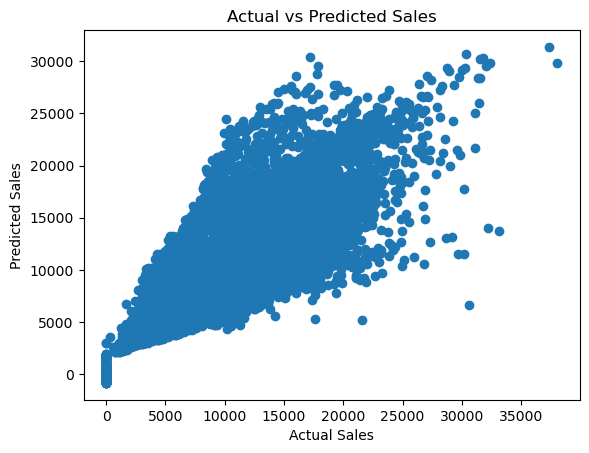

In [71]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()